In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# =========================
# 0) CONFIG (F7 Week 03)
# =========================
SEED = 42
np.random.seed(SEED)

# Paths (as requested)
INPUTS_PATH = "data/F7/initial_inputs.npy"
OUTPUTS_PATH = "data/F7/initial_outputs.npy"

# If you're running this inside the provided sandbox here, uncomment these:
# INPUTS_PATH = "/mnt/data/initial_inputs.npy"
# OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# F7: 6D inputs, assumed scaled to [0,1] already (check in Load section)
BOUNDS = np.array([[0.0, 1.0]] * 6)

MAXIMIZE = True

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

In [7]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

# Ensure shapes
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).reshape(-1)

print("X shape:", X.shape, "y shape:", y.shape)
print("X min/max:", X.min(), X.max())
print("y min/max:", y.min(), y.max())
print("Best observed y:", y.max() if MAXIMIZE else y.min())
print("Best observed X:", X[np.argmax(y)] if MAXIMIZE else X[np.argmin(y)])

# Sanity check: feature-wise ranges
feat_min = X.min(axis=0)
feat_max = X.max(axis=0)
print("\nPer-feature min:", np.round(feat_min, 4))
print("Per-feature max:", np.round(feat_max, 4))


X shape: (32, 6) y shape: (32,)
X min/max: 0.0 0.9986546964586872
y min/max: 0.0027014650245082332 1.5650708126009862
Best observed y: 1.5650708126009862
Best observed X: [0.       0.425878 0.225301 0.207625 0.373905 0.758381]

Per-feature min: [0.     0.0118 0.0036 0.0737 0.0149 0.0511]
Per-feature max: [0.9425 0.9247 0.9246 0.961  0.9987 0.951 ]


In [8]:
# =========================
# 2) SURROGATE MODELS (F7)
# =========================
# Fits: GP (scaled X,y + robust kernel), RF, GBM ensemble
# Notes:
# - GP warnings about length_scale hitting lower bound are handled by scaling + wider bounds + WhiteKernel.
# - RF and GBM work on original scale; their uncertainty is handled later.

import numpy as np
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ----------------------------
# 2.1) Gaussian Process (robust)
# ----------------------------
# Scale X and y for GP stability
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_gp = x_scaler.fit_transform(X)
y_gp = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(
        length_scale=np.ones(X.shape[1]),
        length_scale_bounds=(1e-8, 1e2)  # wider bounds than default
    )
    + WhiteKernel(
        noise_level=1e-5,
        noise_level_bounds=(1e-10, 1e-1)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-8,                # nugget for numerical stability
    normalize_y=False,         # y is already scaled
    n_restarts_optimizer=10,
    random_state=SEED
)

# Fit GP (silence convergence warnings)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gp.fit(X_gp, y_gp)

print("GP fitted. Kernel:", gp.kernel_)

# Helper: predict on ORIGINAL y scale
def gp_predict_original(X_query):
    Xq = x_scaler.transform(X_query)
    mu_z, std_z = gp.predict(Xq, return_std=True)
    mu = y_scaler.inverse_transform(mu_z.reshape(-1, 1)).ravel()
    std = std_z * y_scaler.scale_[0]
    return mu, std

# ----------------------------
# 2.2) Random Forest
# ----------------------------
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X, y)
print("RF fitted.")

# ----------------------------
# 2.3) GBM Ensemble (for uncertainty by spread)
# ----------------------------
# Small ensemble of GBMs with different seeds/subsampling
gbm_ensemble = []
n_gbm = 10

for i in range(n_gbm):
    gbm = GradientBoostingRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=SEED + i
    )
    gbm.fit(X, y)
    gbm_ensemble.append(gbm)

print(f"GBM ensemble fitted (n={n_gbm}).")

print("Surrogates fitted: GP, RF, GBM ensemble")



GP fitted. Kernel: 0.849**2 * RBF(length_scale=[2.19, 100, 100, 0.516, 0.667, 1.6]) + WhiteKernel(noise_level=1e-05)
RF fitted.
GBM ensemble fitted (n=10).
Surrogates fitted: GP, RF, GBM ensemble


In [9]:
# =========================
# 3) UNCERTAINTY ESTIMATION HELPERS
# =========================
from scipy.stats import norm

def gp_predict(Xq):
    """Return (mu, sigma) in original y units."""
    mu_std, std_std = gp.predict(Xq, return_std=True)
    mu = y_scaler.inverse_transform(mu_std.reshape(-1,1)).ravel()
    # Std in original units: scaler.scale_ is std dev
    sigma = std_std * y_scaler.scale_[0]
    sigma = np.maximum(sigma, 1e-12)
    return mu, sigma

def rf_predict_with_uncertainty(Xq, q_lo=0.1, q_hi=0.9):
    """Mean + (std, quantiles) from per-tree predictions."""
    all_tree = np.vstack([t.predict(Xq) for t in rf.estimators_])  # (n_trees, n_points)
    mu = all_tree.mean(axis=0)
    std = all_tree.std(axis=0, ddof=1)
    ql = np.quantile(all_tree, q_lo, axis=0)
    qh = np.quantile(all_tree, q_hi, axis=0)
    std = np.maximum(std, 1e-12)
    return mu, std, ql, qh

def gbm_predict_with_uncertainty(Xq):
    preds = np.vstack([m.predict(Xq) for m in gbm_ensemble])  # (n_models, n_points)
    mu = preds.mean(axis=0)
    std = preds.std(axis=0, ddof=1)
    std = np.maximum(std, 1e-12)
    return mu, std

# quick check on training set uncertainty
mu_gp, s_gp = gp_predict(X)
mu_rf, s_rf, _, _ = rf_predict_with_uncertainty(X)
mu_gb, s_gb = gbm_predict_with_uncertainty(X)

print("GP train mean abs err:", np.mean(np.abs(mu_gp - y)))
print("RF train mean abs err:", np.mean(np.abs(mu_rf - y)))
print("GBM train mean abs err:", np.mean(np.abs(mu_gb - y)))


GP train mean abs err: 0.33196371552379733
RF train mean abs err: 0.09993184096907157
GBM train mean abs err: 0.0003141494398862733


In [10]:
# =========================
# 4) ACQUISITION (MAXIMISATION)
#    We'll compute EI from each surrogate, then blend.
# =========================
def expected_improvement(mu, sigma, y_best, xi=0.01):
    """EI for maximization."""
    imp = mu - y_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-12] = 0.0
    return np.maximum(ei, 0.0)

y_best = y.max() if MAXIMIZE else y.min()

def acquisition(Xq):
    # GP EI
    mu_gp, s_gp = gp_predict(Xq)
    ei_gp = expected_improvement(mu_gp, s_gp, y_best, xi=0.01)

    # RF EI (use mean/std across trees)
    mu_rf, s_rf, _, _ = rf_predict_with_uncertainty(Xq)
    ei_rf = expected_improvement(mu_rf, s_rf, y_best, xi=0.01)

    # GBM EI (ensemble mean/std)
    mu_gb, s_gb = gbm_predict_with_uncertainty(Xq)
    ei_gb = expected_improvement(mu_gb, s_gb, y_best, xi=0.01)

    # Blend (robustness): normalize each to [0,1] then average
    def norm01(a):
        a = np.asarray(a)
        amin, amax = a.min(), a.max()
        return (a - amin) / (amax - amin + 1e-12)

    score = (norm01(ei_gp) + norm01(ei_rf) + norm01(ei_gb)) / 3.0
    return score, (ei_gp, ei_rf, ei_gb), (mu_gp, s_gp, mu_rf, s_rf, mu_gb, s_gb)

# Candidate generation (random + local perturbations around best)
def sample_candidates(n_global=20000, n_local=5000, local_scale=0.08):
    d = X.shape[1]
    # global uniform
    Xg = np.random.rand(n_global, d) * (BOUNDS[:,1] - BOUNDS[:,0]) + BOUNDS[:,0]

    # local around current best point
    x0 = X[np.argmax(y)] if MAXIMIZE else X[np.argmin(y)]
    Xl = x0 + np.random.randn(n_local, d) * local_scale
    Xl = np.clip(Xl, BOUNDS[:,0], BOUNDS[:,1])

    return np.vstack([Xg, Xl])

Xcand = sample_candidates()
score, (ei_gp, ei_rf, ei_gb), preds = acquisition(Xcand)

best_idx = int(np.argmax(score))
x_next = Xcand[best_idx]

print("Best acquisition score:", float(score[best_idx]))
print("Recommended x_next:", np.round(x_next, 6))


Best acquisition score: 0.5481356594713676
Recommended x_next: [0.029608 0.928878 0.45357  0.259055 0.107713 0.743326]


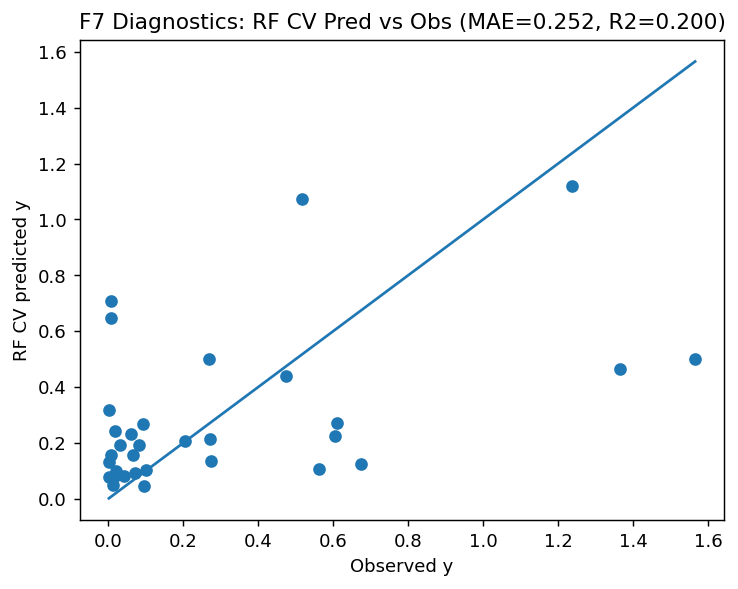

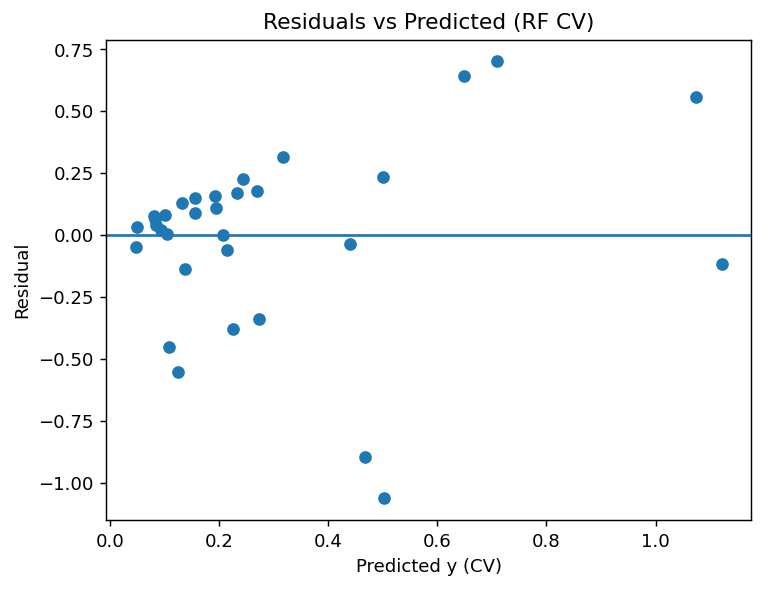

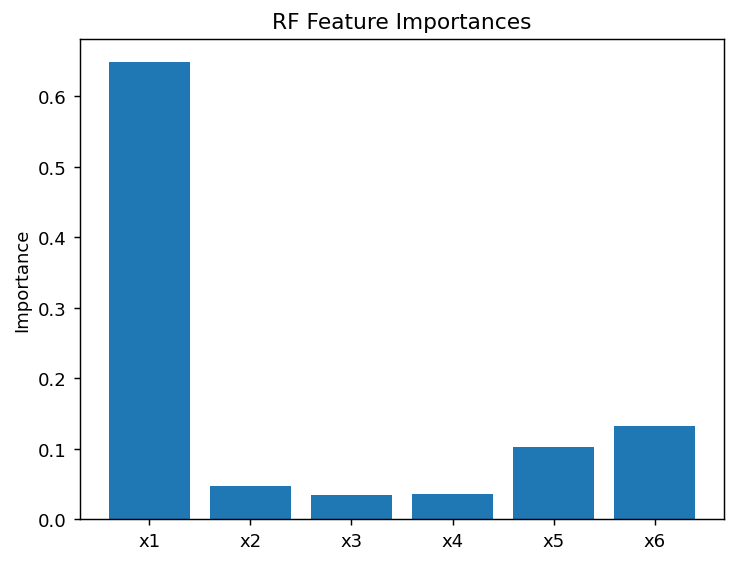

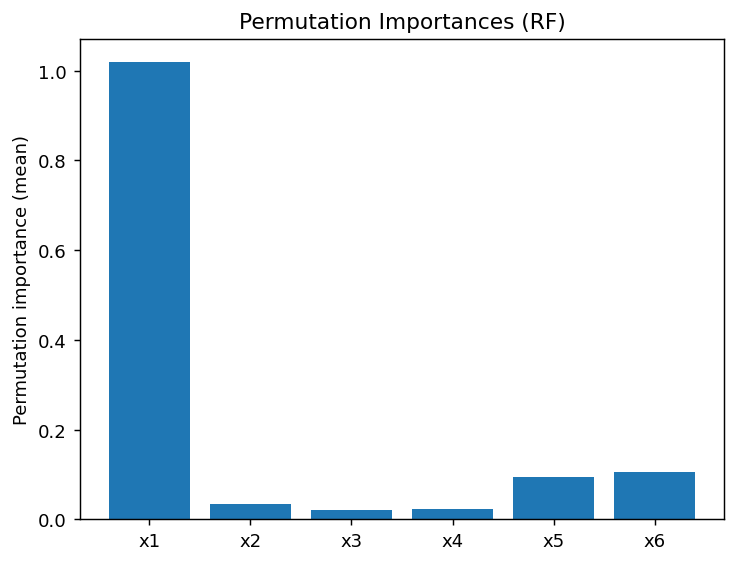

Min Euclidean distance of x_next to existing points: 0.4286399104319235

Top-10 acquisition candidates (rounded):
1 [0.0296 0.9289 0.4536 0.2591 0.1077 0.7433] score= 0.5481356594713676 dmin= 0.4286399104319235
2 [0.0292 0.4891 0.3269 0.2269 0.3162 0.7337] score= 0.4616391030775602 dmin= 0.13456244103717102
3 [0.0224 0.5825 0.648  0.1298 0.0161 0.6555] score= 0.457339490133902 dmin= 0.5263034698171867
4 [0.0184 0.9324 0.56   0.0659 0.0196 0.9984] score= 0.4479451185795036 dmin= 0.6570121184774282
5 [3.330e-02 6.605e-01 6.250e-01 2.235e-01 6.000e-04 9.129e-01] score= 0.42350569727383935 dmin= 0.48405425942978575
6 [0.0152 0.3496 0.6892 0.0619 0.0331 0.7154] score= 0.4230610398612264 dmin= 0.47239693444317027
7 [0.0542 0.2489 0.5292 0.0101 0.006  0.7076] score= 0.41614044816417767 dmin= 0.47454313520561964
8 [0.0231 0.6471 0.8471 0.0669 0.025  0.428 ] score= 0.41127187459741865 dmin= 0.6896724300213444
9 [0.     0.5001 0.1166 0.1564 0.0832 0.5851] score= 0.4063193495298267 dmin= 0.366708

In [11]:
# =========================
# 5) DIAGNOSTICS
#    - Predicted vs observed (CV for RF/GBM, in-sample for GP)
#    - Residuals
#    - Feature importance
#    - Region / diversity checks (distance to existing points)
# =========================
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# --- CV predicted vs observed (RF as main) ---
cv = KFold(n_splits=min(5, len(y)), shuffle=True, random_state=RANDOM_SEED)
yhat_rf_cv = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1)
mae = mean_absolute_error(y, yhat_rf_cv)
r2 = r2_score(y, yhat_rf_cv)

plt.figure(dpi=130)
plt.scatter(y, yhat_rf_cv)
lims = [min(y.min(), yhat_rf_cv.min()), max(y.max(), yhat_rf_cv.max())]
plt.plot(lims, lims)
plt.xlabel("Observed y")
plt.ylabel("RF CV predicted y")
plt.title(f"F7 Diagnostics: RF CV Pred vs Obs (MAE={mae:.3f}, R2={r2:.3f})")
plt.show()

# Residuals
res = yhat_rf_cv - y
plt.figure(dpi=130)
plt.scatter(yhat_rf_cv, res)
plt.axhline(0)
plt.xlabel("Predicted y (CV)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted (RF CV)")
plt.show()

# --- Feature importance (RF built-in + permutation) ---
rf_imp = rf.feature_importances_
plt.figure(dpi=130)
plt.bar(np.arange(X.shape[1]), rf_imp)
plt.xticks(range(X.shape[1]), [f"x{i+1}" for i in range(X.shape[1])])
plt.ylabel("Importance")
plt.title("RF Feature Importances")
plt.show()

perm = permutation_importance(rf, X, y, n_repeats=25, random_state=RANDOM_SEED, n_jobs=-1)
perm_imp = perm.importances_mean
plt.figure(dpi=130)
plt.bar(np.arange(X.shape[1]), perm_imp)
plt.xticks(range(X.shape[1]), [f"x{i+1}" for i in range(X.shape[1])])
plt.ylabel("Permutation importance (mean)")
plt.title("Permutation Importances (RF)")
plt.show()

# --- Not stuck: distance of proposed point to nearest existing point ---
def min_dist_to_existing(x, X):
    return np.min(np.linalg.norm(X - x.reshape(1,-1), axis=1))

dmin = min_dist_to_existing(x_next, X)
print("Min Euclidean distance of x_next to existing points:", float(dmin))

# Show top 10 candidates to sanity-check diversity
topk = 10
top_idx = np.argsort(-score)[:topk]
print("\nTop-10 acquisition candidates (rounded):")
for rank, idx in enumerate(top_idx, 1):
    xk = Xcand[idx]
    print(rank, np.round(xk, 4), "score=", float(score[idx]), "dmin=", float(min_dist_to_existing(xk, X)))


In [12]:
# =========================
# 6) OUTPUT: ONE ROW TO SUBMIT
# =========================
x_submit = x_next.copy()

print("=== RECOMMENDED NEXT X (submit this 1 row) ===")
print(x_submit)

print("\nRounded (6 dp):", np.round(x_submit, 6))


=== RECOMMENDED NEXT X (submit this 1 row) ===
[0.02960835 0.92887789 0.45356983 0.25905515 0.1077129  0.7433261 ]

Rounded (6 dp): [0.029608 0.928878 0.45357  0.259055 0.107713 0.743326]
